# Circuit Scaling

In [1]:
import pennylane as qml
from pennylane import numpy as np
from Pauli_algebra_v3 import *
import matplotlib.pyplot as plt
import itertools
from Random_QLSP_v7_light import *

In [2]:
def shadow_bound_c(error, observables, failure_rate=0.01):
    M = len(observables)
    K = 2 * np.log(2 * M / failure_rate)

    shadow_norm = (
            lambda op: np.linalg.norm(
                op - np.trace(op) / 2 ** int(np.log2(op.shape[0])), ord=np.inf
            )
            ** 2
        )
    list_of_observables = ([qml.pauli.string_to_pauli_word(pstrs) for pstrs in observables])
    list_of_matrices = [qml.matrix(o) for o in list_of_observables]

    return int(np.ceil(np.log(M)*(3**(max(shadow_norm(o) for o in list_of_matrices)))/error**2)), int(K)

In [3]:
def calc_klocality(pstr):
    return pstr.count('X') + pstr.count('Y') + pstr.count('Z')

In [36]:
kappa = 10
n = 50
dim = 2**n
# k_locality = 5
error = 0.01

VQLS_ncircuits = []
SQLS_circuits_k2 = []
SQLS_circuits_k3 = []
SQLS_circuits_k4 = []
SQLS_circuits_k5 = []
SQLS_circuits_k7 = []
SQLS_circuits_kn2 = []

for p in np.linspace(4,2500, 1000):
    n_terms = p*(p-1) + n*p**2
    VQLS_ncircuits.append(0.5*10000*n_terms)
    # k_loc = k_locality*2 + 1
    N_shadow_k2 = int(np.ceil(np.log(n_terms)*(3**5)/error**2))
    N_shadow_k3 = int(np.ceil(np.log(n_terms)*(3**7)/error**2))
    N_shadow_k4 = int(np.ceil(np.log(n_terms)*(3**9)/error**2))
    N_shadow_k5 = int(np.ceil(np.log(n_terms)*(3**11)/error**2))
    N_shadow_k7 = int(np.ceil(np.log(n_terms)*(3**15)/error**2))
    N_shadow_kn2 = int(np.ceil(np.log(n_terms)*(3**(n/8 + 1))/error**2))
    
    SQLS_circuits_k2.append(N_shadow_k2)
    SQLS_circuits_k3.append(N_shadow_k3)
    SQLS_circuits_k4.append(N_shadow_k4)
    SQLS_circuits_k5.append(N_shadow_k5)
    SQLS_circuits_k7.append(N_shadow_k7)
    SQLS_circuits_kn2.append(N_shadow_kn2)

In [37]:
color = ['#aadce0',
 '#ef8a47',
 '#376795',
 '#f7aa58',
 '#72bcd5',
 '#ffe6b7',
 '#e76254',
 '#1e466e',
 '#ffd06f',
 '#528fad']

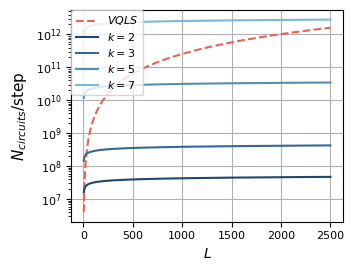

In [40]:
number_of_unitaries = np.linspace(4,1000, 20)
plt.figure(figsize=(3.5,2.75))

plt.plot(np.linspace(4,2500, 1000), VQLS_ncircuits,label=r'$VQLS$', color= '#e76254', linestyle = 'dashed')
plt.plot(np.linspace(4,2500, 1000), SQLS_circuits_k2, label = r'$k=2$', color = '#1e466e')   
plt.plot(np.linspace(4,2500, 1000), SQLS_circuits_k3, label = r'$k=3$', color = '#376795')   
plt.plot(np.linspace(4,2500, 1000), SQLS_circuits_k5, label = r'$k=5$', color = '#528fad')   
plt.plot(np.linspace(4,2500, 1000), SQLS_circuits_k7, label = r'$k=7$', color = '#72bcd5')   


plt.xlabel(r'$L$')
plt.ylabel(r'$N_{circuits}$/step', fontsize = 11, labelpad=12, va = 'center')
plt.yticks(fontsize = 8)
plt.xticks(fontsize = 8)
# plt.ylim(1e10,2.5e12)
plt.yscale("log")
plt.grid()
plt.legend(loc='upper left', borderaxespad=0, fontsize = 8, labelspacing = 0.35)#, ncol = 3)
plt.savefig('Operatorscaling_v4.pdf', bbox_inches = 'tight')